# Karan Dattatray Tormal

## Data Science – Task 1
### Iris Flower Classification

First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  Setosa  
1       0  Setosa  
2       0  Setosa  
3       0  Setosa  
4       0  Setosa  

Dataset Shape:
(150, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal 

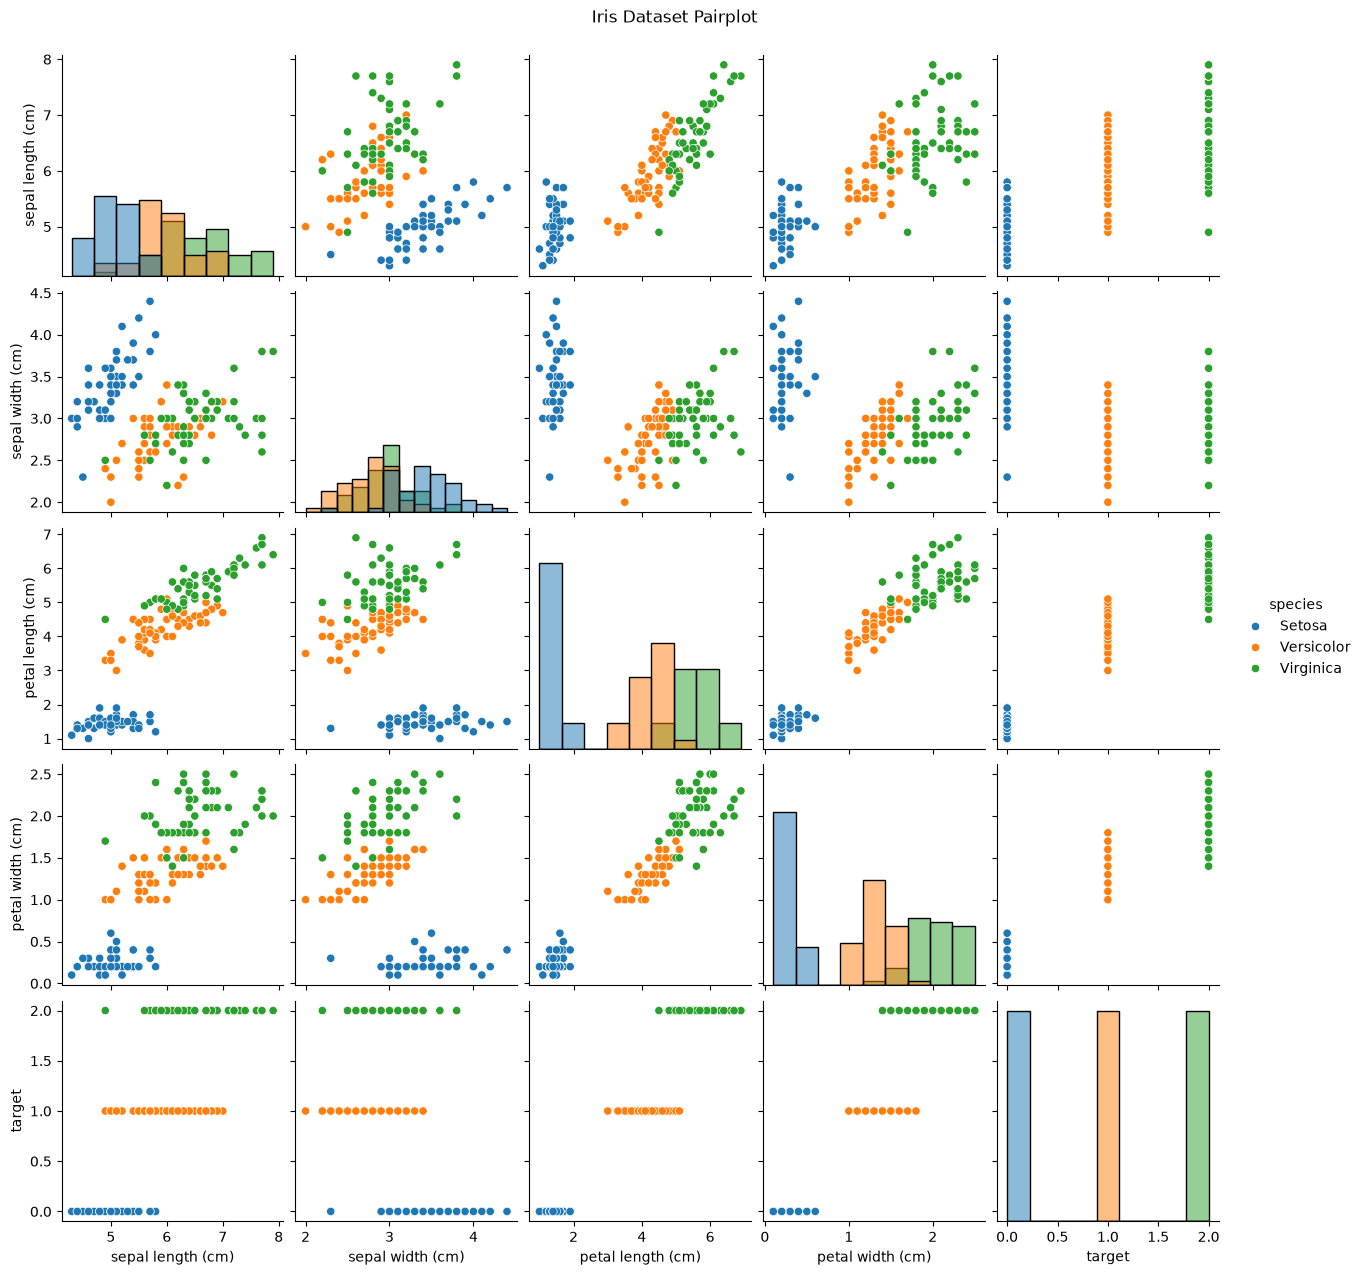

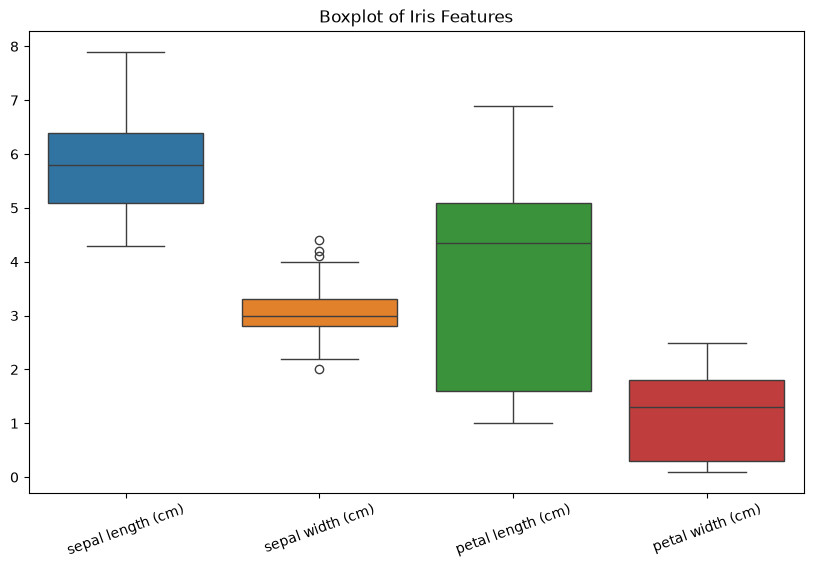

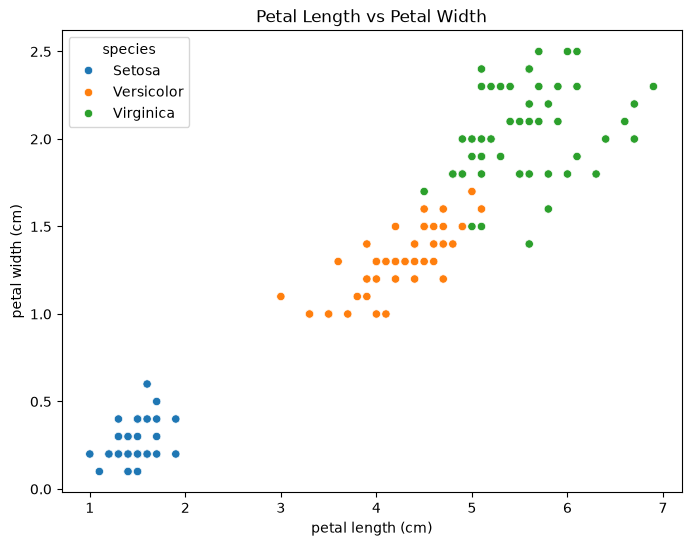


Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)

LOGISTIC REGRESSION
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



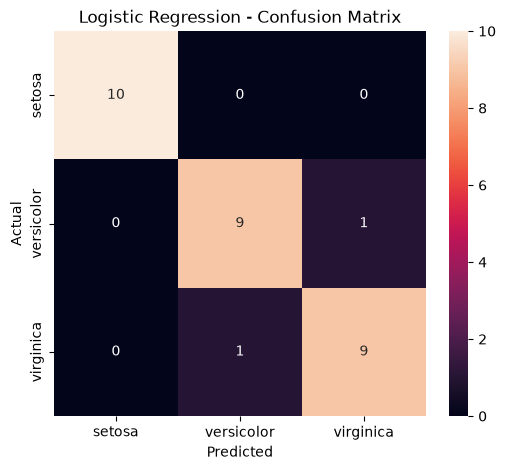


K-NEAREST NEIGHBORS
Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



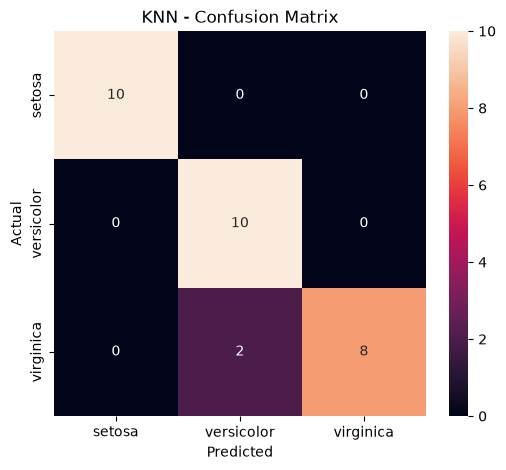


MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.933333
1  K-Nearest Neighbors  0.933333


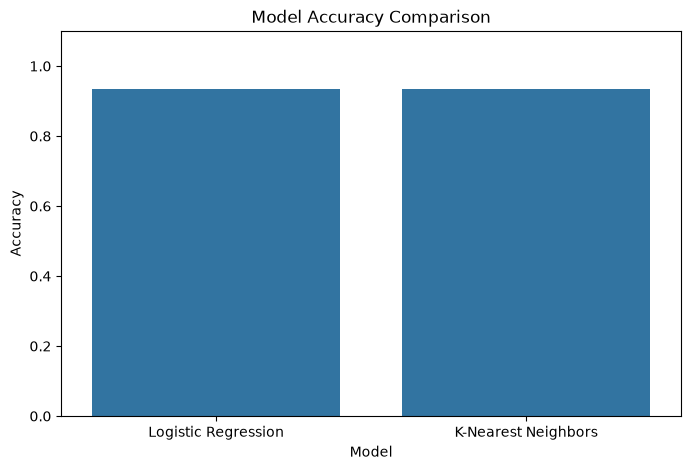


BEST MODEL
Best Model: Logistic Regression
Best Accuracy: 0.9333333333333333

CONCLUSION

The Iris Flower Classification dataset was analyzed using
Exploratory Data Analysis and visualization techniques.

Two machine learning classification models were implemented:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)

Both models were evaluated using accuracy, precision, recall,
F1-score and confusion matrix.

Petal length and petal width were found to be highly useful
features for distinguishing between the three Iris species:
Setosa, Versicolor and Virginica.

The best-performing model was:

Logistic Regression
with an accuracy of: 0.9333333333333333


In [6]:
# ============================================================
# OIBSIP DATA SCIENCE TASK 1
# IRIS FLOWER CLASSIFICATION
# ============================================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print("First 5 Rows:")
print(df.head())


# ============================================================
# 3. EXPLORATORY DATA ANALYSIS
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nSpecies Count:")
print(df["species"].value_counts())


# ============================================================
# 4. DATA VISUALIZATION
# ============================================================

# Pairplot
sns.pairplot(df, hue="species", diag_kind="hist")
plt.suptitle("Iris Dataset Pairplot", y=1.02)
plt.show()


# Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[
        [
            "sepal length (cm)",
            "sepal width (cm)",
            "petal length (cm)",
            "petal width (cm)"
        ]
    ]
)

plt.xticks(rotation=20)
plt.title("Boxplot of Iris Features")
plt.show()


# Petal Length vs Petal Width
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Petal Length vs Petal Width")
plt.show()


# ============================================================
# 5. PREPARE DATA
# ============================================================

X = df[
    [
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
]

y = df["target"]


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 8. MODEL 1 - LOGISTIC REGRESSION
# ============================================================

model_lr = LogisticRegression(max_iter=200)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("\n====================================")
print("LOGISTIC REGRESSION")
print("====================================")

print("Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=iris.target_names
    )
)


# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# ============================================================
# 9. MODEL 2 - K NEAREST NEIGHBORS
# ============================================================

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("\n====================================")
print("K-NEAREST NEIGHBORS")
print("====================================")

print("Accuracy:", accuracy_knn)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)


# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()


# ============================================================
# 10. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_knn
    ]
})

print("\n====================================")
print("MODEL COMPARISON")
print("====================================")

print(results)


# Accuracy Comparison Graph
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


# ============================================================
# 11. FIND BEST MODEL
# ============================================================

if accuracy_lr >= accuracy_knn:
    best_model = "Logistic Regression"
    best_accuracy = accuracy_lr
else:
    best_model = "K-Nearest Neighbors"
    best_accuracy = accuracy_knn

print("\n====================================")
print("BEST MODEL")
print("====================================")

print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy)


# ============================================================
# 12. FINAL CONCLUSION
# ============================================================

print("\n====================================")
print("CONCLUSION")
print("====================================")

print("""
The Iris Flower Classification dataset was analyzed using
Exploratory Data Analysis and visualization techniques.

Two machine learning classification models were implemented:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)

Both models were evaluated using accuracy, precision, recall,
F1-score and confusion matrix.

Petal length and petal width were found to be highly useful
features for distinguishing between the three Iris species:
Setosa, Versicolor and Virginica.

The best-performing model was:
""")

print(best_model)
print("with an accuracy of:", best_accuracy)